# Steam Games Analysis

## Step 1: Problem Definition & Dataset Selection

**Objective:** To analyze the factors that contribute to a game's success on Steam, focusing on the relationship between genres, price, and user ratings.

**Dataset Source:** The dataset is from Kaggle and can be found at [https://www.kaggle.com/datasets/nikdavis/steam-store-games](https://www.kaggle.com/datasets/nikdavis/steam-store-games).

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import ttest_ind

# Set the style for plots
sns.set_style('whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('steam.csv')
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


**Dataset Overview:**

In [3]:
df.shape

(27075, 18)

**Variable Types:**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

## Step 2: Data Cleaning & Preparation

In [5]:
# Check for missing values
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

**Justification:** There are no missing values in the dataset, so no imputation or removal is needed.

In [6]:
# Convert 'release_date' to datetime
df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year

**Justification:** Converting the `release_date` column to a datetime object allows us to extract the year and perform time-based analysis.

## Step 3: Exploratory Data Analysis (EDA)

In [7]:
# Descriptive statistics
df.describe()

,appid,release_date,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,release_year
count,2.707500e+04,27075,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000,27075.000000
mean,5.962035e+05,2016-12-31 14:21:17.252077568,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193,2016.498098
min,1.000000e+01,1997-06-30 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000,1997.000000
25%,4.012300e+05,2016-04-04 00:00:00,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000,2016.000000
50%,5.990700e+05,2017-08-08 00:00:00,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000,2017.000000
75%,7.987600e+05,2018-06-06 12:00:00,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000,2018.000000
max,1.069460e+06,2019-05-01 00:00:00,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000,2019.000000
std,2.508942e+05,NaN,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922,2.156990


**Insight:** The descriptive statistics provide a summary of the numerical columns. We can see the mean, standard deviation, and other useful metrics.

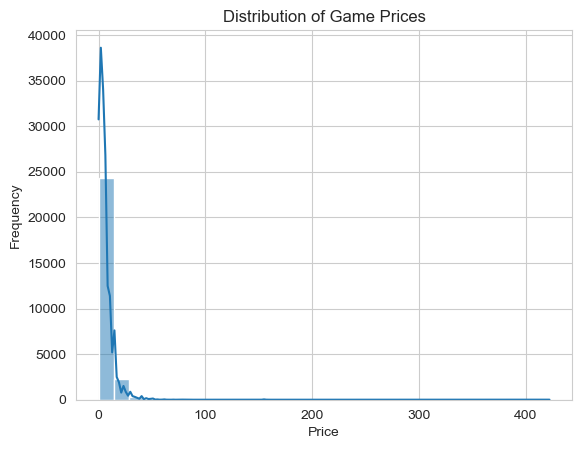

In [8]:
# Price distribution
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Game Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Insight:** The price distribution is heavily skewed to the right, with most games being relatively inexpensive.

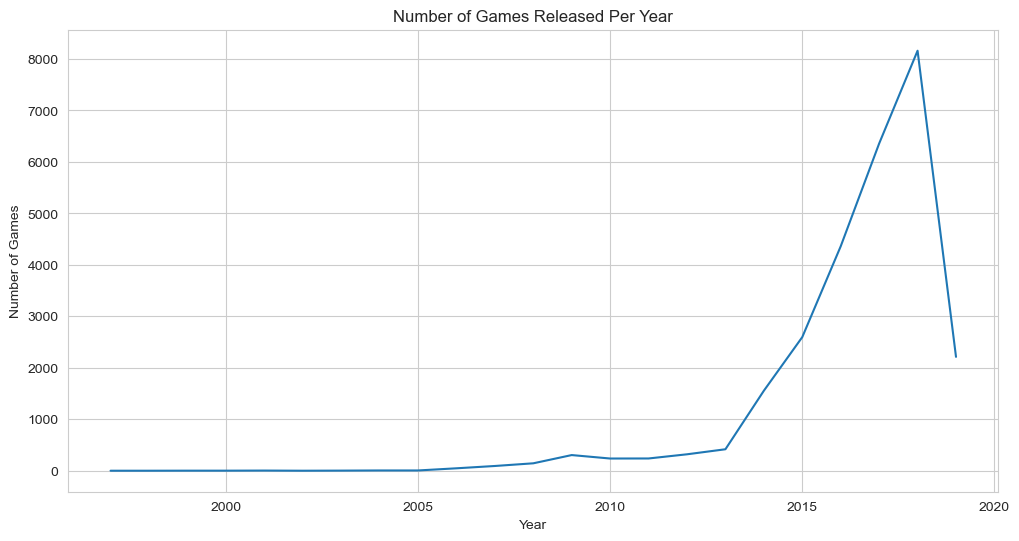

In [9]:
# Games released per year
plt.figure(figsize=(12, 6))
df.groupby('release_year')['appid'].count().plot()
plt.title('Number of Games Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.grid(True)
plt.show()

**Insight:** There has been a significant increase in the number of games released on Steam over the years, with a particularly sharp increase in recent years.

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

ValueError: could not convert string to float: 'Counter-Strike'

<Figure size 1200x800 with 0 Axes>

**Insight:** The correlation heatmap shows the relationships between numerical variables. For example, we can see a strong positive correlation between `positive_ratings` and `negative_ratings`.